## Hämtar in data och kikar lite: Priotera misstänkta annonser.
Kravkort 1-Trust & Safety: "Vi får inte missa de värsta"
Stakeholder:Maja, Head of Trust & Safety.
Prioritet: Maximera recall(fånga så många misstänkta fall som möjligt).
Fokus är beslut/prioritering utifrån kravkortet – inte att maximera en siffra.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import os 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.model_selection import (
    StratifiedKFold, 
    cross_validate, 
    train_test_split, 
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

df = pd.read_csv('../data/historical_data.csv')
df = pd.DataFrame(df)

# Skriv ut de första 5 raderna för att dubbelkolla att det ser bra ut
df.head(10)

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0
5,5,11,message_send,phones,rural,android,31.9,6,0,2,502.33,5,247,0,0,0,26.3,0
6,6,6,message_send,electronics,rural,android,133.9,9,0,0,46.40,2,188,0,0,0,3.2,0
7,7,3,ad_post,other,metro,android,5.8,3,0,0,209.24,4,0,0,0,1,3.5,0
8,8,14,message_send,fashion,urban,web,38.7,4,0,0,41.47,2,135,0,0,1,14.6,0
9,9,1,message_send,other,rural,android,71.1,1,1,1,432.86,6,88,0,0,1,21.8,0


## Undersöker datan: Dataförståelse &EDA.
Visa datasetstorlek, datatyper och target-fördelning.
Kontrollera saknade värden och beskriv hur ni hanterar dem.
Minst 2 figurer/tabeller + kort tolkning.


In [2]:


print(df.shape)
print(df.info())
print(df.dtypes)

print("\nMissing values per column:\n", df.isna().sum())
print("\nRegion - because we have missing values:\n", df["region"].value_counts(dropna=False))
print("\nTime to first response - because we have missing values:\n", df["time_to_first_response_min"].value_counts(dropna=False))

print("\nTarget distribution\n", df["is_suspicious"].value_counts(normalize=True)) # Hur fördelningen av vår target "suspicious vs non sucpicious" ser ut




(12000, 18)
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  str    
 3   category                    12000 non-null  str    
 4   region                      11660 non-null  str    
 5   device                      12000 non-null  str    
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains_off_platform       12

## Checkar numerisk information (medelvärde, minsta, max, varians etc)

In [3]:
df.describe()

,id,day,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11182.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11410.000000,12000.000000
mean,5999.50000,7.482667,99.632567,3.027750,0.151500,0.710167,207.348603,2.870417,111.154417,0.072833,0.099083,0.181167,22.160438,0.102000
std,3464.24595,4.032520,112.903541,1.766467,0.386083,0.719171,196.226023,1.766886,66.396885,0.259874,0.298786,0.385172,28.834047,0.302661
min,0.00000,1.000000,2.200000,0.000000,0.000000,0.000000,7.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,0.000000
25%,2999.75000,4.000000,36.300000,2.000000,0.000000,0.000000,86.195000,2.000000,63.000000,0.000000,0.000000,0.000000,6.700000,0.000000
50%,5999.50000,7.000000,66.600000,3.000000,0.000000,1.000000,149.225000,3.000000,108.000000,0.000000,0.000000,0.000000,13.400000,0.000000
75%,8999.25000,11.000000,120.700000,4.000000,0.000000,1.000000,256.795000,4.000000,155.000000,0.000000,0.000000,0.000000,26.600000,0.000000
max,11999.00000,14.000000,2741.700000,12.000000,3.000000,2.000000,2743.080000,10.000000,416.000000,1.000000,1.000000,1.000000,579.800000,1.000000


## Heatmap för de numeriska värdena 

4 variabler har en positiv korrelation med vår target "is_suspicious"

- contains_off_platform
- urgency_words
- payment_attempt
- prev_reports_30d

**Note**: Det som korrelerar negativt med vår target verkar vara account_age_days (desto längre ett konto funnits desto lägre sannolikhet att det utför bedrägrerier)


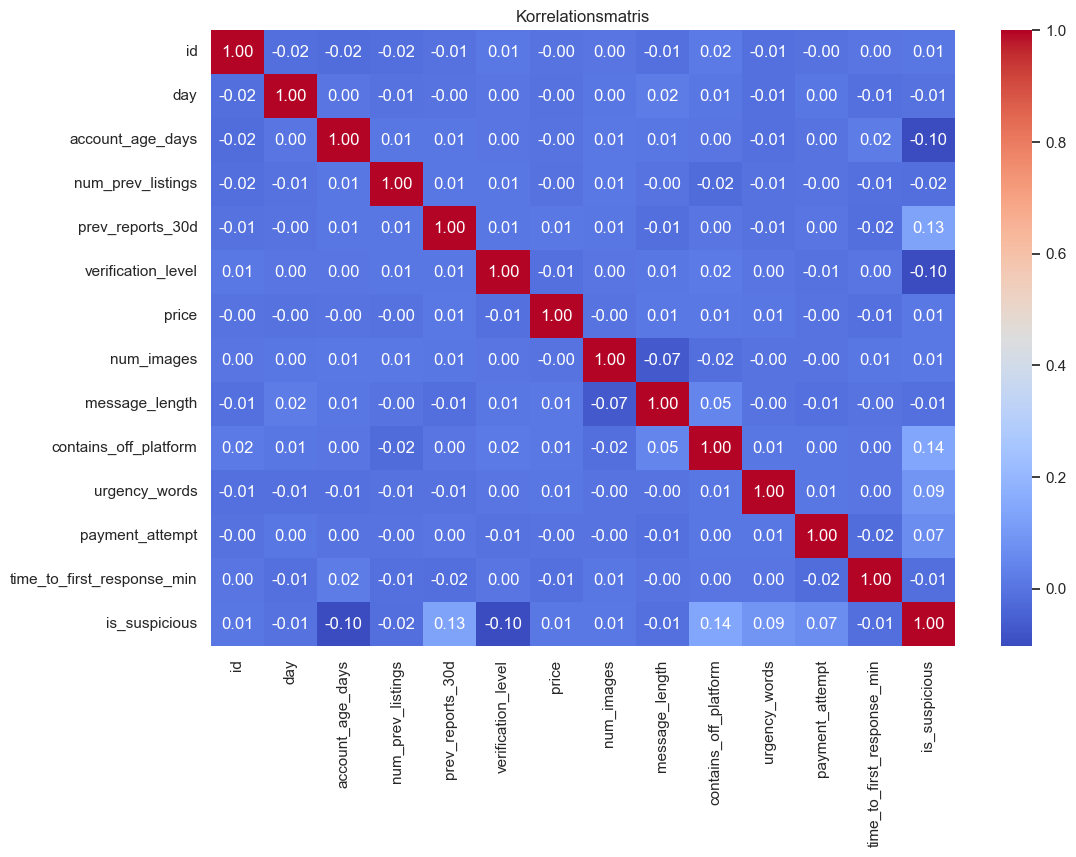

In [4]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korrelationsmatris')
plt.show()

### Kikar på hur många unika värden varje string kolumn innehar (hur många kategorier som finns i vardera)

För många unika värden gör string kolumnen svår att bruka, men här har vi mellan 2-6 unika värden vilket är mycket goda nyheter


In [5]:
string_cols = df.select_dtypes(include=['object', 'str']).columns

for col in string_cols:
    print(f"{col}: {df[col].nunique()} unika värden")

event_type: 2 unika värden
category: 6 unika värden
region: 3 unika värden
device: 3 unika värden


### Tabel 1 - Target-fördelning & saknade värden.
Obalanserad data: ca 18% misstänkta. Saknade värden i region ca 5% och time_to_first_response_min ca 10%.
Dessa imputeras med medianen(numeriska) och vanligaste värdet(kategoriska).

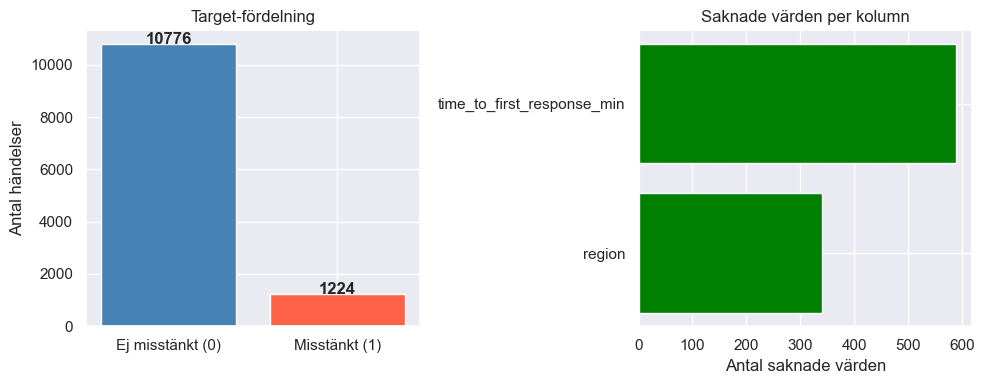

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1 – Target-fördelning
counts = df["is_suspicious"].value_counts()
axes[0].bar(["Ej misstänkt (0)", "Misstänkt (1)"], counts.values,
            color=["steelblue", "tomato"], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")
axes[0].set_title("Target-fördelning")
axes[0].set_ylabel("Antal händelser")

# plot 2 - Saknade värden.
missing = df.isna().sum()
missing = df.drop(columns=['price']).isna().sum()
missing = missing[missing > 0]
axes[1].barh(missing.index, missing.values, color="green")
axes[1].set_title('Saknade värden per kolumn')
axes[1].set_xlabel('Antal saknade värden')

plt.tight_layout()
plt.show()

## Kikar på lite korrelationer med vår target

- Vi inser här att bland "account_age_days" så finns det en hel del outliers (förmodligen inaktiva konton). 
- Skickas en extern länk i kommunikationen mellan köpare/säljare så ökar sannolikheten att det är en bedragare

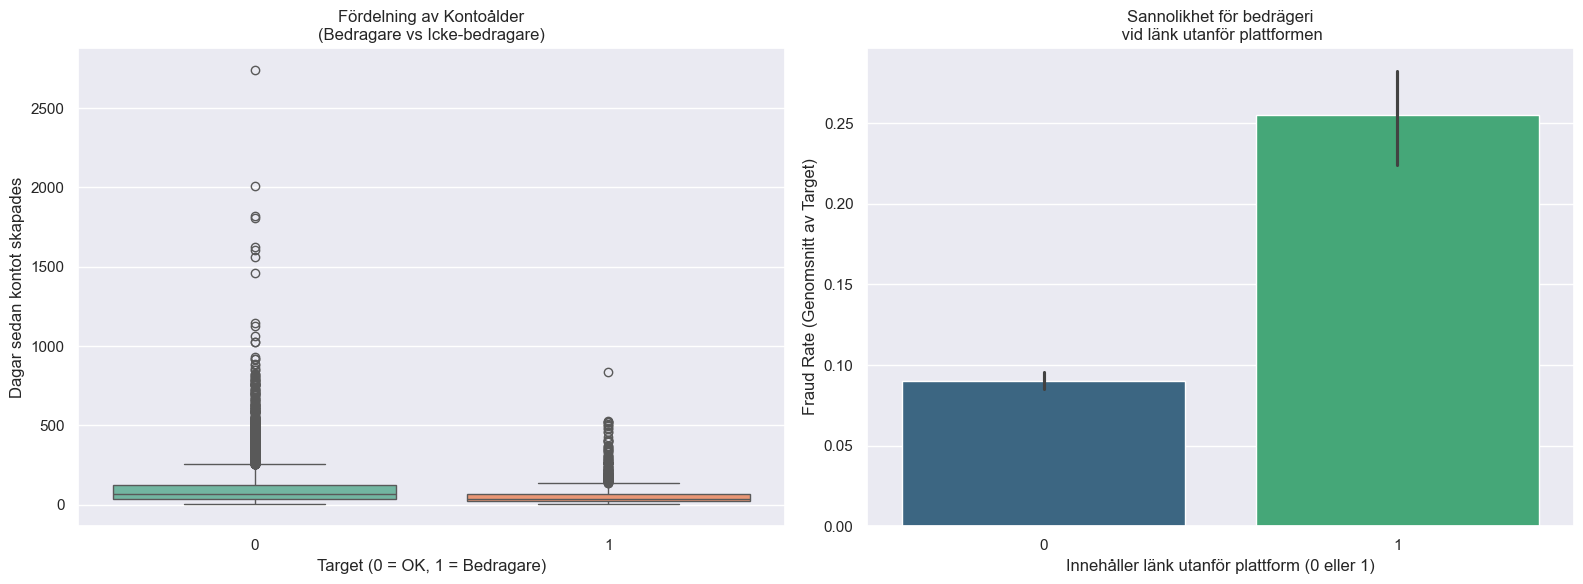

In [7]:
target = "is_suspicious"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Kontots ålder vs potentiellt bedrägeriförsök
sns.boxplot(x=target, y='account_age_days', hue=target,
            data=df, ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Fördelning av Kontoålder\n(Bedragare vs Icke-bedragare)')
axes[0].set_xlabel('Target (0 = OK, 1 = Bedragare)')
axes[0].set_ylabel('Dagar sedan kontot skapades')

# Plot 2 - Sannolikheten för bedrägeri baserat på om de har skickat en länk eller ej
sns.barplot(x='contains_off_platform', y=target, hue='contains_off_platform',
    data=df, ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Sannolikhet för bedrägeri\n vid länk utanför plattformen')
axes[1].set_xlabel('Innehåller länk utanför plattform (0 eller 1)')
axes[1].set_ylabel('Fraud Rate (Genomsnitt av Target)')

plt.tight_layout()
plt.show()

## Train/test + preprocessing

**Att fånga så många verkligt misstänkta fall som möjligt.**
Alltså en binär klassificering:
- 1 = farligt / misstänkt 
- 0 = inte farligt
- `is_suspicious` = 1 → farligt fall
- `is_suspicious` = 0 → normalt fall

In [8]:
X = df.drop(target, axis=1)
y = df[target]

if "id" in X.columns:
    X = X.drop(columns=["id"])


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Train proportion:\n", y_train.value_counts(normalize=True))
print("Test proportion:\n", y_test.value_counts(normalize=True))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train proportion:
 is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64
Test proportion:
 is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64
Train shape: (9600, 16)
Test shape: (2400, 16)


In [10]:
# Identifiera numeriska/kategoriska kolumner:

numeric_features = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool", 'str']).columns.tolist()

print("\nNumerical:", numeric_features)
print("Categorical:", categorical_features)


Numerical: ['day', 'account_age_days', 'num_prev_listings', 'prev_reports_30d', 'verification_level', 'price', 'num_images', 'message_length', 'contains_off_platform', 'urgency_words', 'payment_attempt', 'time_to_first_response_min']
Categorical: ['event_type', 'category', 'region', 'device']


In [11]:
# Preprocessing pipelines

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 4) ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ],
    remainder="drop"
)

In [12]:
# Pipeline (no leakage) - sanity check och fit endast på train:

pipeline_sanity = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED))
])

pipeline_sanity.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

## Modellering och Jämförelse

In [13]:
# Moddeller / Jämföra
models = {
    'Baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200, class_weight='balanced')
}

# Corss validation, Stratified ser till att varje fold får nästan samma andel som en hel data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Metrics jämföra
# Precision - kolla hur många av de flaggade som verkligen var misstänkta
# Recall = koll hur stor andel av alla misstänkta man hittar
# f1 = balans mellan precision oc reccall

scoring = {
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
}

# Körs cv för varje modell och sparar resultat
rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])

    cv_result = cross_validate(pipe, X, y, cv=cv, scoring=scoring)

    rows.append({
        'Model': name,
        'precision': cv_result['test_precision'].mean(),
        'recall': cv_result['test_recall'].mean(),
        'f1': cv_result['test_f1'].mean(),
    })

results = pd.DataFrame(rows).sort_values('f1', ascending=False)

print('\nFeatures:')
print('Numeriska: ', len(numeric_features), numeric_features[:5])
print('Kategoriska: ', len(categorical_features), categorical_features)

# Bästa modellen enligt Recall
best_recall = results.sort_values('recall', ascending=False).iloc[0]
# Bästa modell enligt F1, balans mellan precision och recall
best_f1 = results.sort_values('f1', ascending=False).iloc[0]

print('\n-- Bäst enligt Recall --')
print(
    'Model:', best_recall['Model'],
    'Recall:', round(best_recall['recall'], 3),
    'Precision:', round(best_recall['precision'], 3),
    'F1:', round(best_recall['f1'], 3)
)

print('\n-- Bäst enligt F1 --')
print(
    'Model:', best_f1['Model'],
    'F1:', round(best_f1['f1'], 3),
    'Recall:', round(best_f1['recall'], 3),
    'Precision:', round(best_f1['precision'], 3)
)

print('\n-- Resultat --')
print(results)



Features:
Numeriska:  12 ['day', 'account_age_days', 'num_prev_listings', 'prev_reports_30d', 'verification_level']
Kategoriska:  4 ['event_type', 'category', 'region', 'device']

-- Bäst enligt Recall --
Model: Logistic Regression Recall: 0.632 Precision: 0.192 F1: 0.294

-- Bäst enligt F1 --
Model: Logistic Regression F1: 0.294 Recall: 0.632 Precision: 0.192

-- Resultat --
                 Model  precision    recall        f1
1  Logistic Regression   0.191545  0.632385  0.293968
2        Random Forest   0.453333  0.007357  0.014445
0             Baseline   0.000000  0.000000  0.000000


## Modelloptimering

Vi optimerar den modell som presterade bäst i steg 3: **Random Forest**, med fokus på **recall** enligt kravkortet. Datasetet är obalanserat, därför används `class_weight='balanced'` och `StratifiedKFold` för att behålla klassfördelningen i varje fold.

Tuningen hålls liten och motiverad och fokuserar på två centrala hyperparametrar:

- **n_estimators** – påverkar modellens stabilitet  
- **max_depth** – styr komplexitet och risken för överfitting  

Vi använder **RandomizedSearchCV** för att hitta den kombination som maximerar recall. Tabellen visar bästa recall och de parametrar som gav bäst resultat.


In [14]:
# STEG 4 – MODELLOPTIMERING (Logistic Regression)

# Vi sätter upp pipelinen med LogisticRegression
lr_pipe = Pipeline([
    ('preprocess', preprocessor), 
    ('model', LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced', max_iter=2000))
])

# Parameterdistribution för Logistic Regression
# C: Regulariseringsstyrka (lägre värde = starkare regularisering)
# penalty: Typ av bestraffning (l1 eller l2)
# solver: Algoritmen som löser optimeringen (liblinear fungerar bra för små dataset och l1)
param_dist = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']  # 'liblinear' krävs för att köra 'l1' i scikit-learn
}

search = RandomizedSearchCV(
    lr_pipe,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

# Formaterar snyggt
params_str = "\n".join([f"{k.replace('model__', '')}: {v}" for k, v in search.best_params_.items()])

result_table = pd.DataFrame({
    "Modell": ["Logistic Regression"],
    "Bästa recall (cv)": [round(search.best_score_, 4)],
    "Bästa parametrar": [params_str]
})

display(result_table.style.set_properties(**{'white-space': 'pre-wrap', 'text-align': 'left'}))

best_model = search.best_estimator_

c:\Users\Jakob\Desktop\Github-projekt\ML_Gruppuppgift\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Jakob\Desktop\Github-projekt\ML_Gruppuppgift\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Modell,Bästa recall (cv),Bästa parametrar
0,Logistic Regression,0.701700,solver: liblinear penalty: l1 C: 0.01


## Top-X prioritering 
Modellen ger en risk score (probability) för varje rad.
Trust & Safety granskar bara de mest riskabla först.

Vårt kravkort säger: **"Vi får inte missa de värsta fallen."** Det betyder att det är viktigare att hitta så många misstänkta fall som möjligt än att minimera antalet falska larm, därför fokuserar jag på recall och använder en Top-X prioriteringsstrategi, på så sätt säkerställer vi att de mest riskabla aktiviteterna alltid granskas först.

In [15]:
# STEG 5 - PRIORITERING MED TOP-X 

# Predikterar sannolikheter på testdatan först:
y_proba = best_model.predict_proba(X_test)[:,1]

results = pd.DataFrame({
    "true_label" : y_test,
    "risk_score" : y_proba
})

# Sorterar högst risk först:
results = results.sort_values("risk_score", ascending=False)

total_suspicious = results["true_label"].sum()

top_values = [0.01, 0.05, 0.10, 0.20, 0.30]

rows = []

for top in top_values:
    n = int(len(results) * top)
    subset = results.head(n)
    found = subset["true_label"].sum()
    recall = found / total_suspicious
    rows.append({
        "Top % reviewed" : int(top * 100),              # hur stor andel av alla annonser/händelser Trust&Safety tittar på; ANDEL GRANSKADE %
        "Cases reviewed" : n,                           # hur många annonser/händerlser teamet faktiskt måste granska; ANTAL GRANSKADE FALL
        "Suspicious found" : int(found),                # hur många verkliga bedrägerier modellen lyckas fånga; ANTAL MISSTÄNKTA HITTADE
        "Recall" : recall                               # hur stor del av alla bedrägerier i datan vi lyckas fånga; RECALL- ANDEL BEDRÄGERIER HITTADE
    })

top_x_table = pd.DataFrame(rows)
top_x_table

,Top % reviewed,Cases reviewed,Suspicious found,Recall
0,1,24,12,0.048980
1,5,120,41,0.167347
2,10,240,75,0.306122
3,20,480,124,0.506122
4,30,720,156,0.636735


Resultaten visar att:
- Om Trust & Safety granskar 10% av aktiviteterna hittar vi ungefär 33% av alla misstänkta fall.
- Om teamet granskar 20% hittar vi cirka 51% av bedrägerierna.
- Om de granskar 30% hittar vi ungefär 64% av alla misstänkta aktiviteter.

Det innebär att ju fler aktiviteter teamet granskar, desto fler bedrägerier kan modellen hjälpa till att identifiera.

### En figur på det:

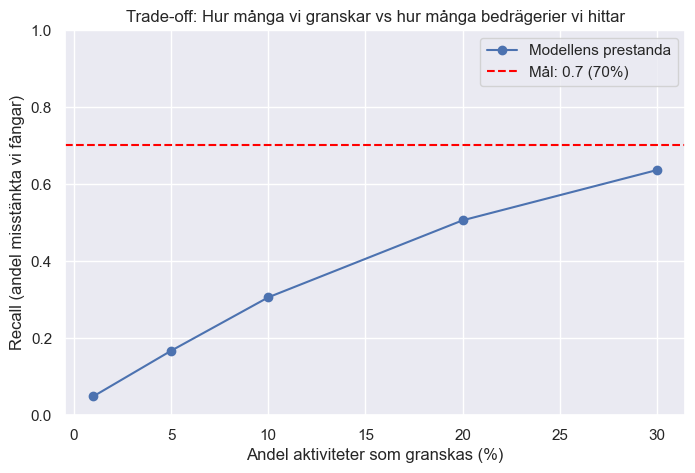

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(top_x_table["Top % reviewed"], top_x_table["Recall"], marker="o", label="Modellens prestanda")


plt.axhline(y=[round(search.best_score_, 4)], color='red', linestyle='--', label="Mål: 0.7 (70%)")


plt.ylim(0, 1)

plt.xlabel("Andel aktiviteter som granskas (%)")
plt.ylabel("Recall (andel misstänkta vi fångar)")
plt.title("Trade-off: Hur många vi granskar vs hur många bedrägerier vi hittar")
plt.grid(True)
plt.legend() 
plt.show()

Efter att vi tidigare har valt och optimerat vår modell (Logistic Regression) behövde vi i gruppen bestämma hur modellen ska användas i praktiken. Istället för att modellen automatiskt tar beslut använder vi den som ett prioriteringsverktyg för Trust & Safety-teamet.

Modellen ger varje aktivitet **en risk score (sannolikhet att vara misstänkt)**.
Vi sorterade därför alla aktiviteter efter denna risk och analyserade vad som händer om teamet granskar de mest riskabla först.

Testade nivåer:
- Top 1%
- Top 5%
- Top 10%
- Top 20%
- Top 30%

För varje nivå räknade vi ut:
- hur många fall som granskas
- hur många verkligt misstänkta fall som hittas
- hur stor andel av alla misstänkta fall vi fångar (recall)

## Rekommendation

En rimlig strategi är att Trust & Safety-teamet granskar **minst de 20% mest riskabla aktiviteterna**.

Det gör att över hälften av alla misstänkta fall upptäcks samtidigt som arbetsbelastningen fortfarande är hanterbar.